# Earth Customer Intelligence System
## End-to-End Unsupervised + Supervised Learning on Country Data

> **Internship Project | Celebal Technologies | Data Science**  
> **Dataset:** Unsupervised Learning on Country Data (Kaggle)  
> **Author:** Abhinav Mishra

---

### Project Objective
Build a **Customer Intelligence System** that:
1. **Segments** countries into meaningful clusters using K-Means & DBSCAN
2. **Classifies** new records using ensemble models (Random Forest, XGBoost, Gradient Boosting)
3. **Generates actionable insights** on country development levels to guide humanitarian aid decisions

### Workflow Overview
```
Data Loading → EDA → Feature Scaling → Clustering (K-Means + DBSCAN)
→ PCA Visualization → Cluster Labeling → Classification (RF + XGBoost + GB)
→ Model Evaluation → Feature Importance → Final Insights
```

## 1. Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, classification_report,
                              confusion_matrix, accuracy_score, f1_score)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.inspection import permutation_importance

import xgboost as xgb

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Dataset

In [7]:
import io
from google.colab import files

# Upload the file if it's not already present
try:
    df = pd.read_csv('Country-data.csv')
except FileNotFoundError:
    uploaded = files.upload()
    if 'Country-data.csv' in uploaded:
        df = pd.read_csv(io.BytesIO(uploaded['Country-data.csv']))
    else:
        raise ValueError("Country-data.csv not found. Please upload the file.")

# Standardise column names
df.columns = [c.strip().lower() for c in df.columns]

print(f"Dataset shape: {df.shape}")
display(df.head(10))

Saving Country-data.csv to Country-data.csv
Saving data-dictionary.csv to data-dictionary.csv
Dataset shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
5,Argentina,14.50,18.90,8.10,16.00,18700,20.90,75.80,2.37,10300
6,Armenia,18.10,20.80,4.40,45.30,6700,7.77,73.30,1.69,3220
7,Australia,4.80,19.80,8.73,20.90,41400,1.16,82.00,1.93,51900
8,Austria,4.30,51.30,11.00,47.80,43200,0.87,80.50,1.44,46900
9,Azerbaijan,39.20,54.30,5.88,20.70,16000,13.80,69.10,1.92,5840


## 3. Exploratory Data Analysis (EDA)

In [8]:
# Basic info
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df.describe(include='all').T

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.00,NaN,NaN,NaN,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,NaN,NaN,NaN,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,NaN,NaN,NaN,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,NaN,NaN,NaN,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,NaN,NaN,NaN,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,NaN,NaN,NaN,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,NaN,NaN,NaN,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,NaN,NaN,NaN,2.95,1.51,1.15,1.79,2.41,3.88,7.49
gdpp,167.00,NaN,NaN,NaN,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [9]:
# Missing value check
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"Duplicates   : {df.duplicated().sum()}")

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing: 0
Duplicates   : 0


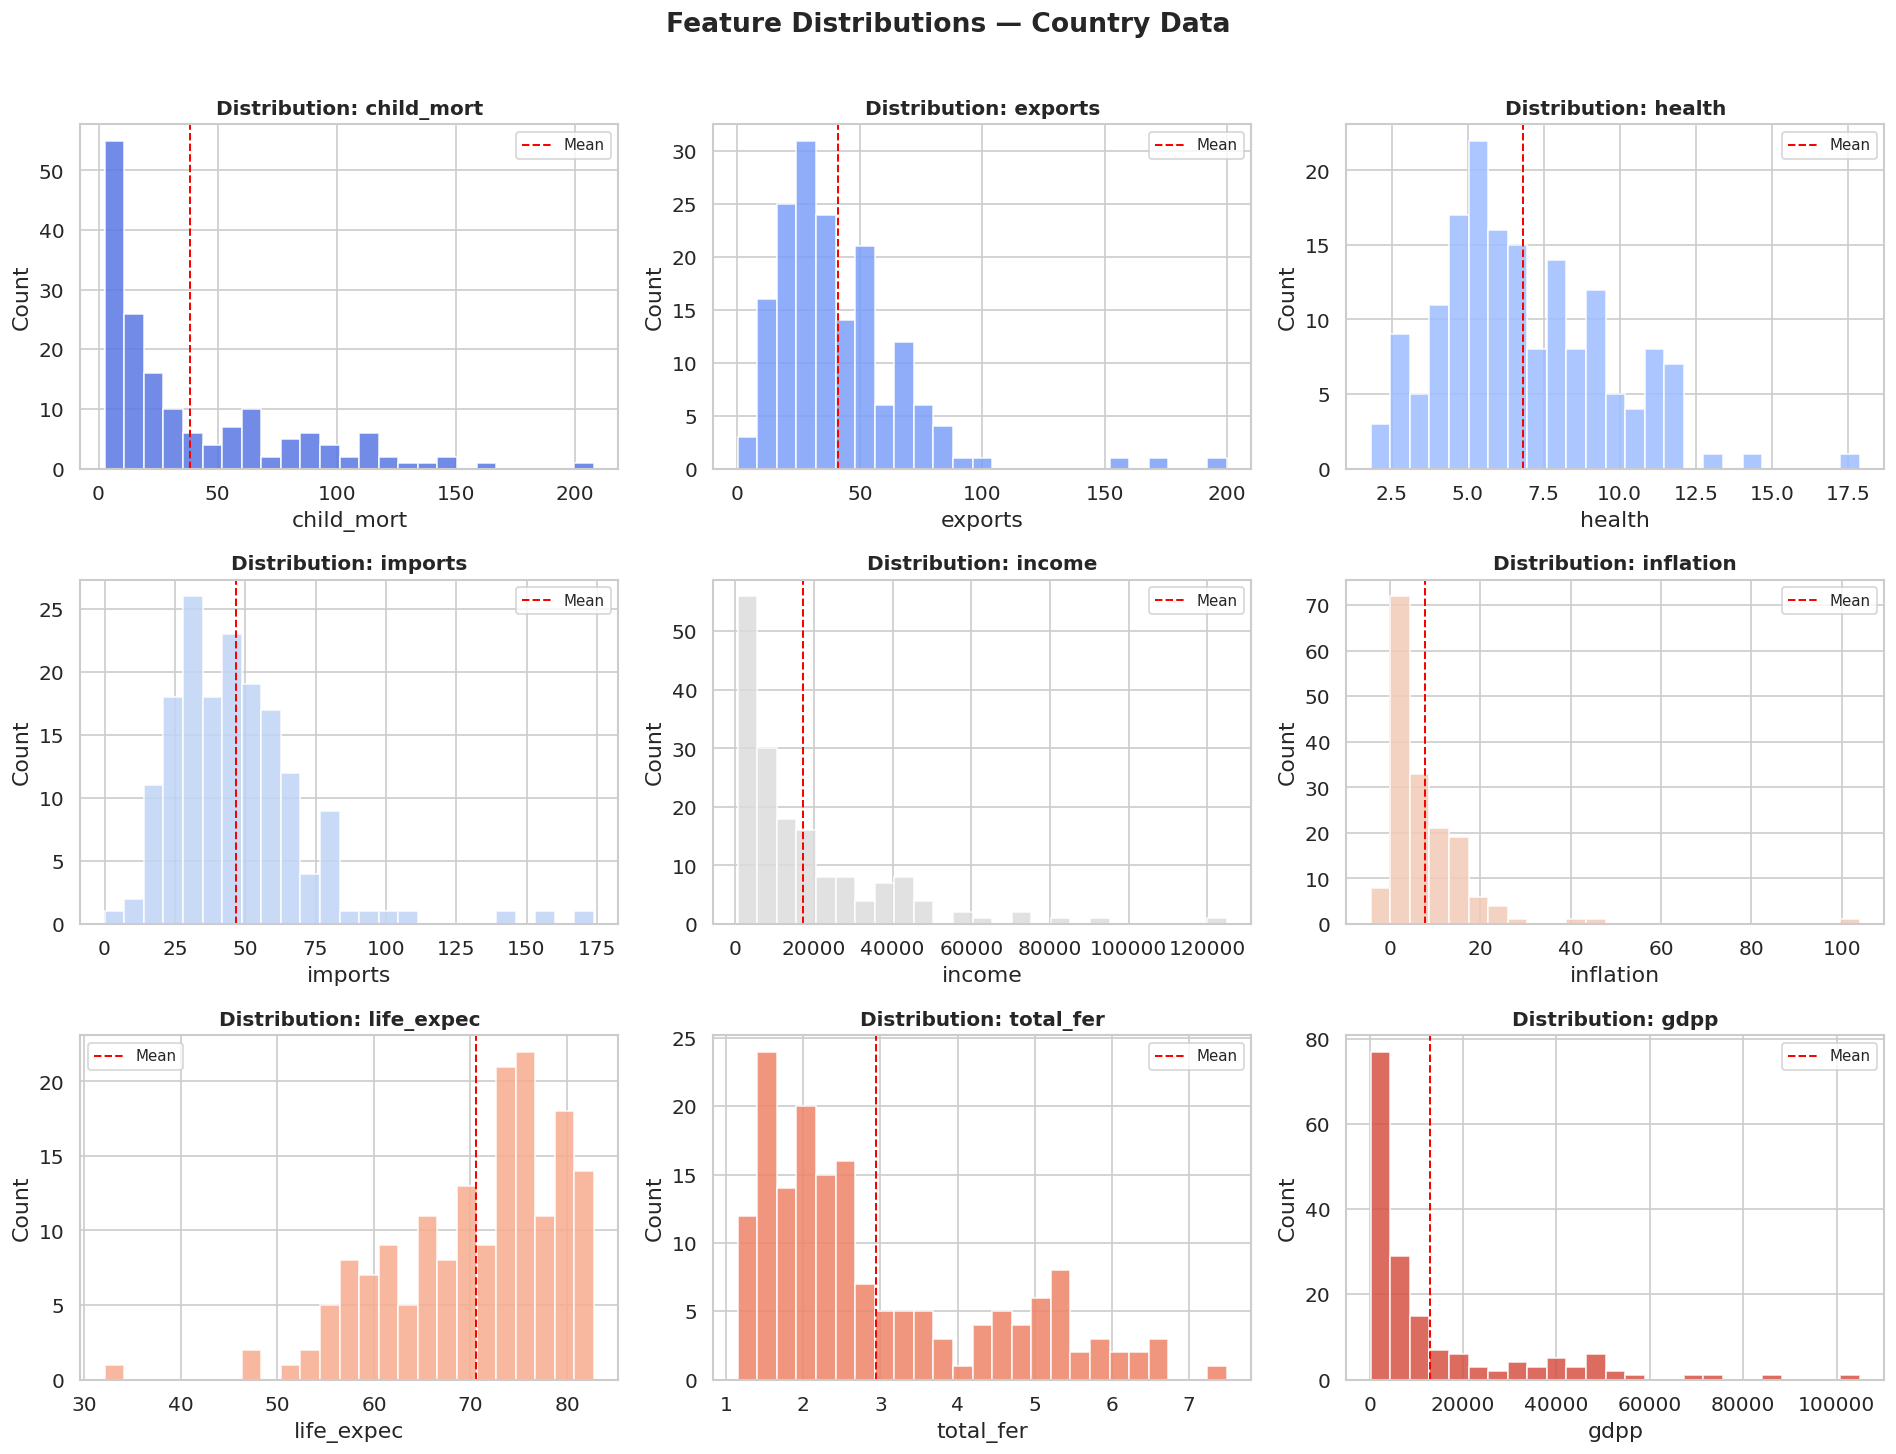

In [10]:
# Distribution plots for all numeric features
numeric_cols = [c for c in df.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors = sns.color_palette("coolwarm", len(numeric_cols))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='Mean')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions — Country Data', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

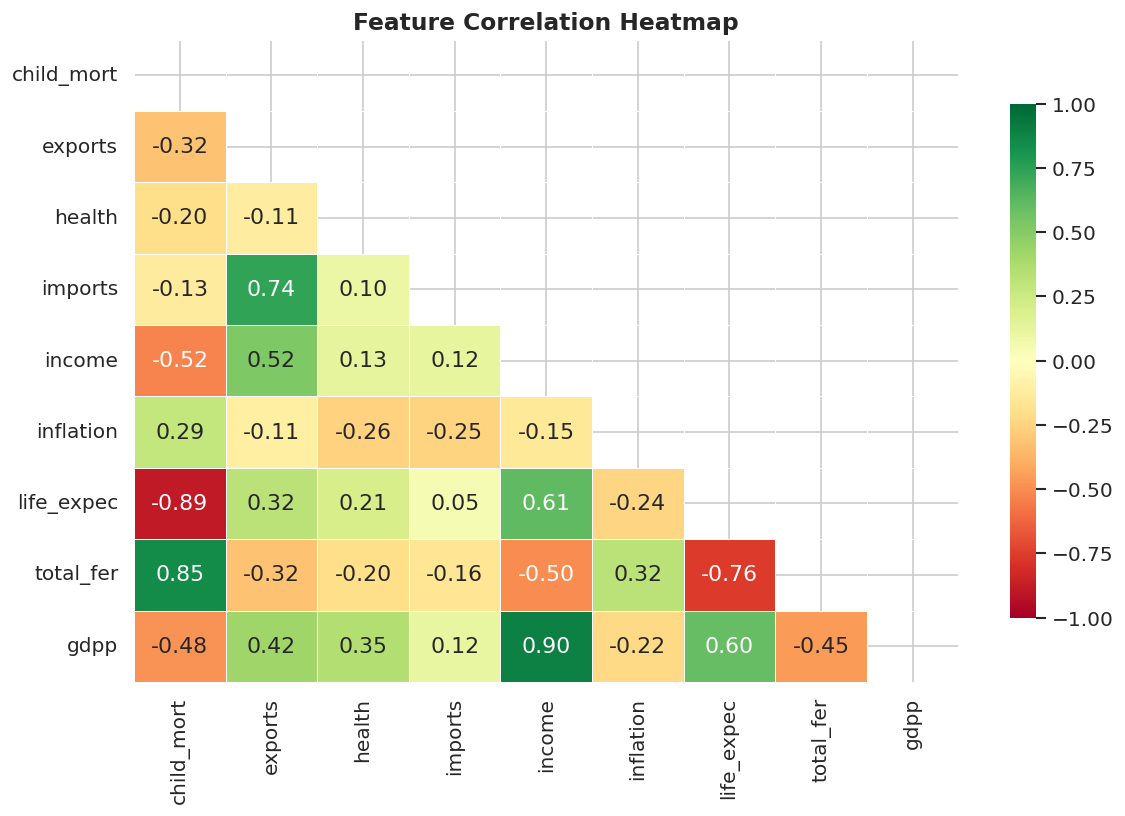


🔍 Key Correlations:
  • child_mort ↔ life_expec : strong negative (as expected)
  • income ↔ gdpp           : strong positive
  • total_fer ↔ life_expec  : moderate negative


In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Key Correlations:")
print("  • child_mort ↔ life_expec : strong negative (as expected)")
print("  • income ↔ gdpp           : strong positive")
print("  • total_fer ↔ life_expec  : moderate negative")

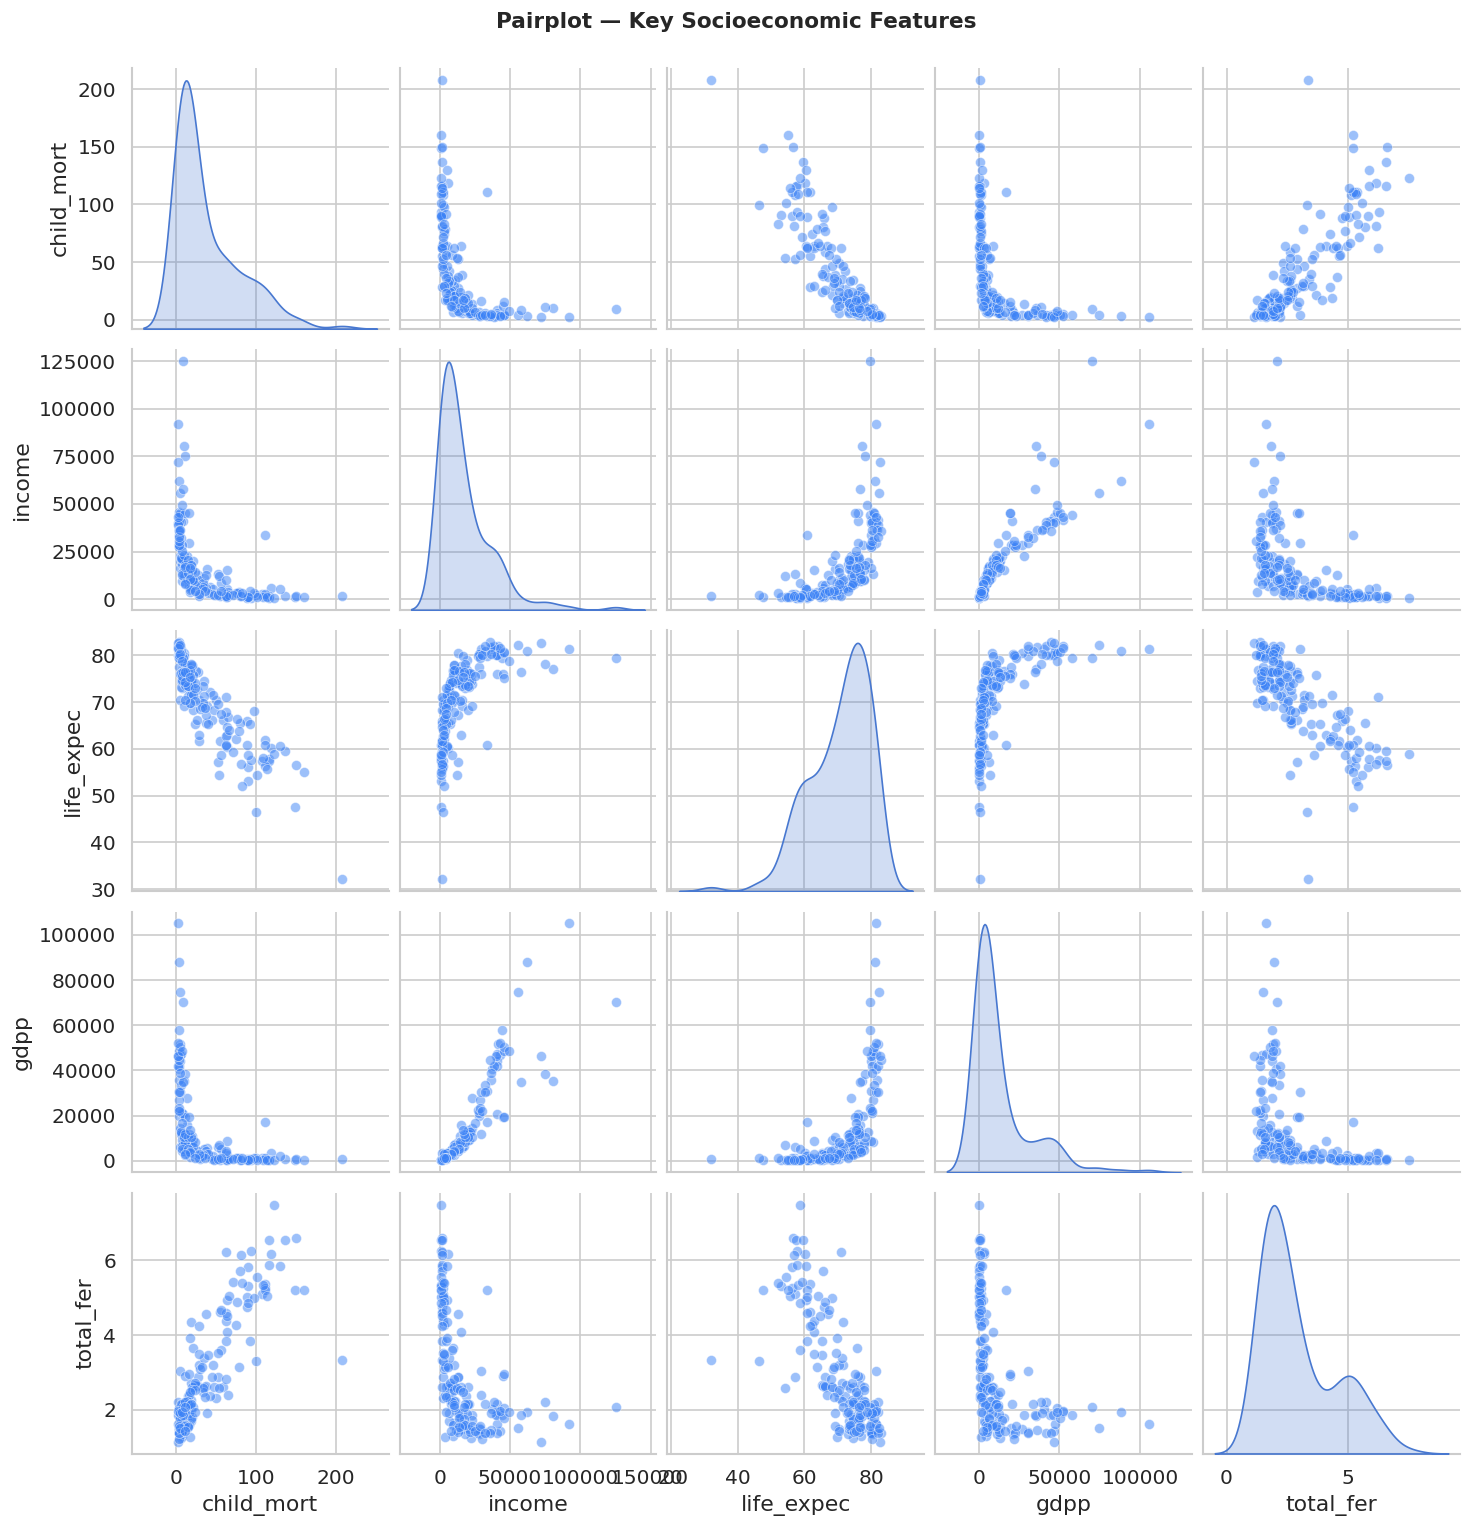

In [12]:
# Pairplot — key features only
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#3b82f6'})
plt.suptitle('Pairplot — Key Socioeconomic Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

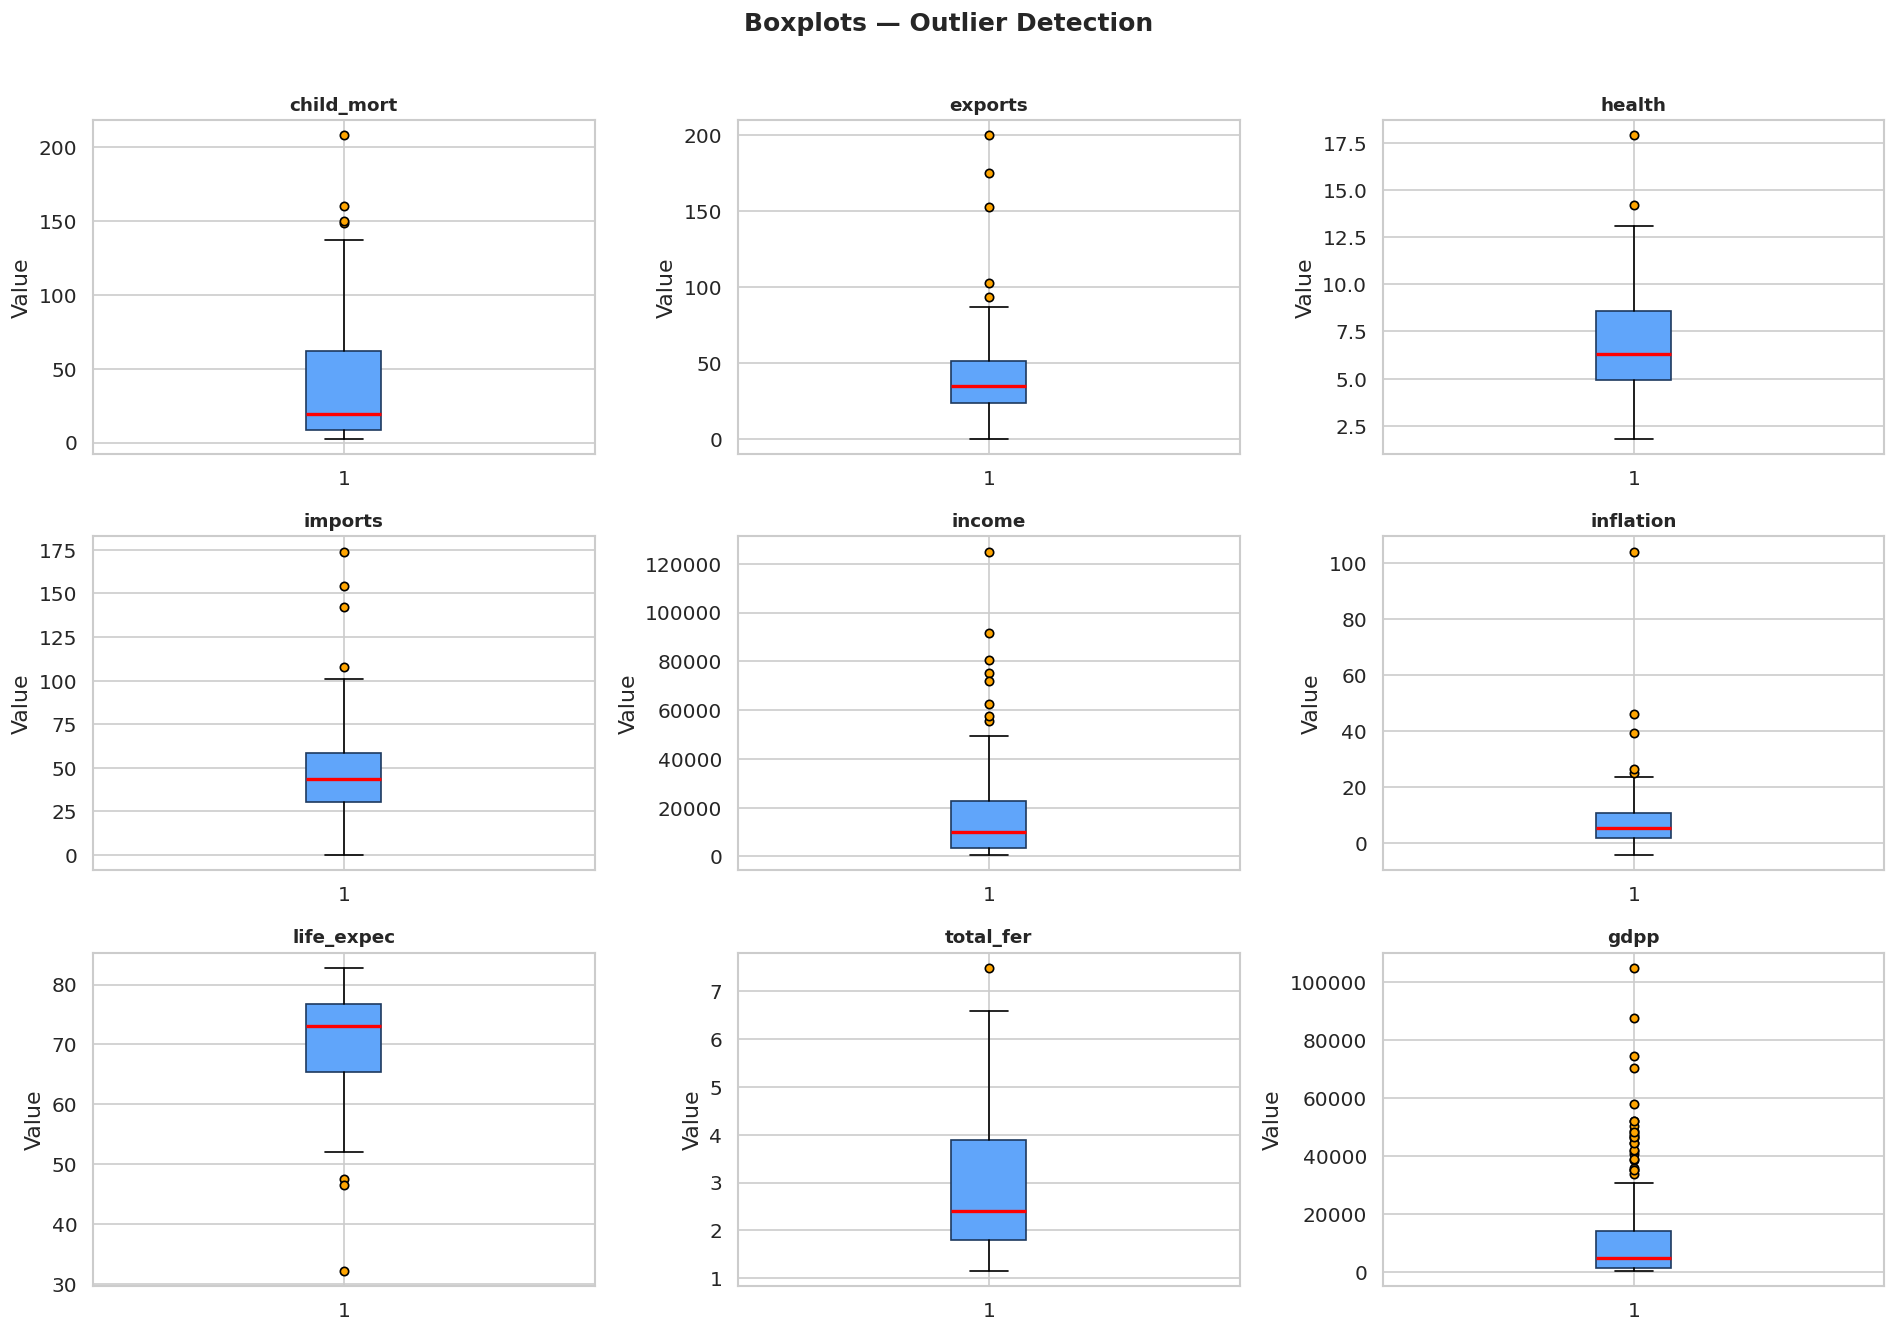

In [13]:
# Boxplots — outlier detection
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#60a5fa', color='#1e3a5f'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=5))
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Feature Scaling

In [14]:
# Clean
df = df.copy()
df = df.drop_duplicates()

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f"✅ Data cleaned. Shape: {df.shape}")
print("Missing after cleaning:", df[numeric_cols].isnull().sum().sum())

✅ Data cleaned. Shape: (167, 10)
Missing after cleaning: 0


In [15]:
# StandardScaler
features = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Mean ≈ 0: {X_scaled.mean(axis=0).round(4)}")
print(f"Std  ≈ 1: {X_scaled.std(axis=0).round(4)}")

Scaled feature matrix shape: (167, 9)
Mean ≈ 0: [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  ≈ 1: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Clustering — K-Means

### 5a. Elbow Method

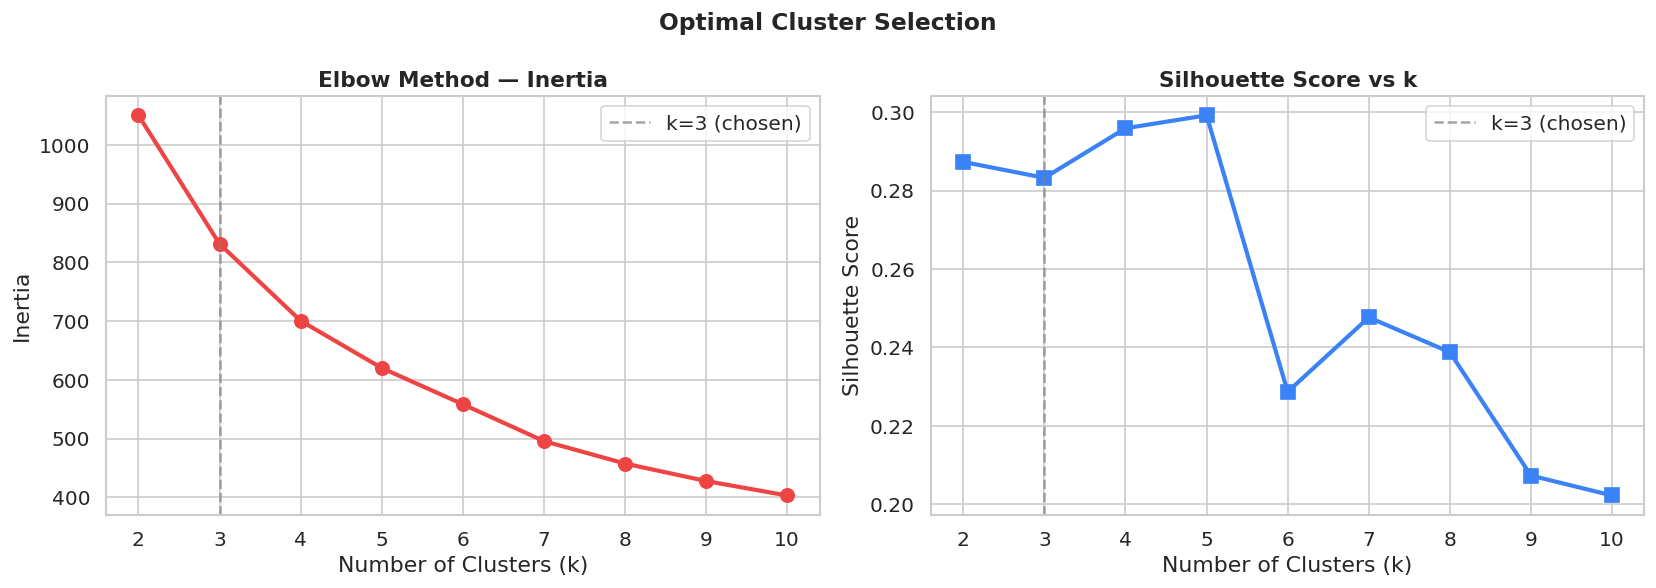


Best Silhouette Score at k=3: 0.2833


In [16]:
# Elbow + Silhouette scores
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#ef4444', linewidth=2.5, markersize=8)
ax1.axvline(3, color='gray', linestyle='--', alpha=0.7, label='k=3 (chosen)')
ax1.set_title('Elbow Method — Inertia', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)'); ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(list(k_range), silhouettes, 's-', color='#3b82f6', linewidth=2.5, markersize=8)
ax2.axvline(3, color='gray', linestyle='--', alpha=0.7, label='k=3 (chosen)')
ax2.set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)'); ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.suptitle('Optimal Cluster Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest Silhouette Score at k=3: {silhouettes[1]:.4f}")

### 5b. Train K-Means (k=3)

In [17]:
BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"✅ K-Means trained | k={BEST_K} | Silhouette Score = {sil:.4f}")
print("\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

✅ K-Means trained | k=3 | Silhouette Score = 0.2833

Cluster distribution:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


### 5c. Try DBSCAN

In [18]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster distribution (−1 = noise):")
print(df['dbscan_cluster'].value_counts().sort_index())

n_noise = (df['dbscan_cluster'] == -1).sum()
n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
print(f"\nClusters found: {n_clusters}  |  Noise points: {n_noise}")

# DBSCAN silhouette (exclude noise)
mask = df['dbscan_cluster'] != -1
if mask.sum() > 1 and len(df.loc[mask, 'dbscan_cluster'].unique()) > 1:
    db_sil = silhouette_score(X_scaled[mask], df.loc[mask, 'dbscan_cluster'])
    print(f"DBSCAN Silhouette (non-noise): {db_sil:.4f}")
else:
    print("Silhouette not applicable (too few valid clusters)")

DBSCAN cluster distribution (−1 = noise):
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Clusters found: 1  |  Noise points: 30
Silhouette not applicable (too few valid clusters)


### 5d. PCA Visualization

PCA Explained Variance: PC1=45.95%, PC2=17.18%, Total=63.13%


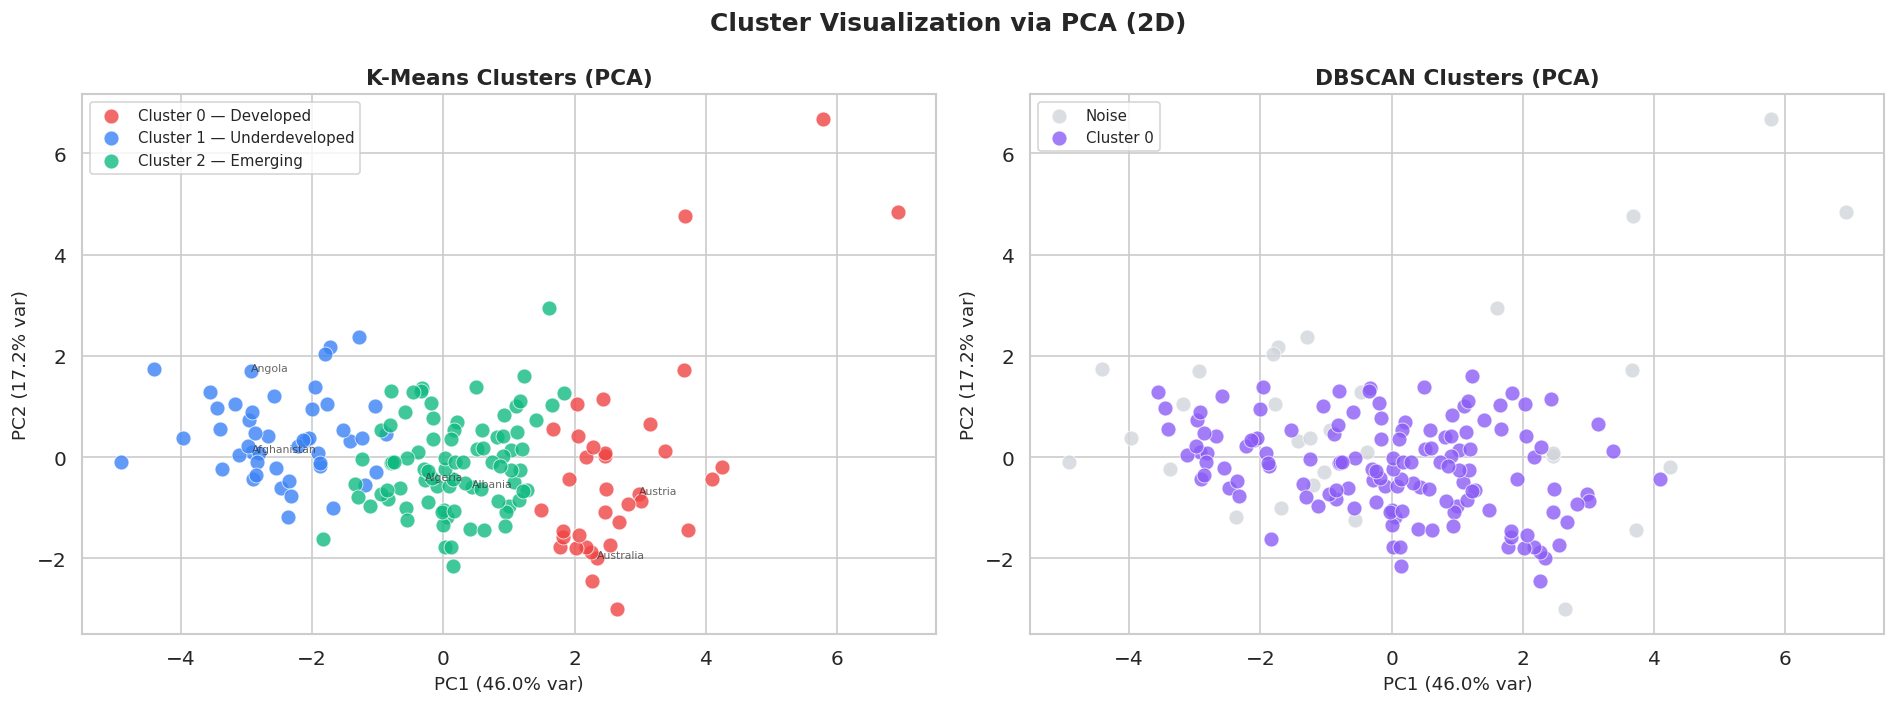

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"PCA Explained Variance: PC1={ev[0]:.2%}, PC2={ev[1]:.2%}, Total={sum(ev):.2%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
palette = {0: '#ef4444', 1: '#3b82f6', 2: '#10b981'}
cluster_names = {0: 'Developed', 1: 'Underdeveloped', 2: 'Emerging'}

for cl, color in palette.items():
    mask = df['kmeans_cluster'] == cl
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=f"Cluster {cl} — {cluster_names[cl]}",
                alpha=0.8, edgecolors='white', linewidth=0.5, s=80)
    # Annotate a few countries
    subset = df[mask].head(2)
    for _, row in subset.iterrows():
        ax1.annotate(row['country'], (X_pca[df.index.get_loc(_), 0],
                     X_pca[df.index.get_loc(_), 1]),
                     fontsize=6.5, alpha=0.7)

ax1.set_xlabel(f'PC1 ({ev[0]:.1%} var)', fontsize=11)
ax1.set_ylabel(f'PC2 ({ev[1]:.1%} var)', fontsize=11)
ax1.set_title('K-Means Clusters (PCA)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

# DBSCAN
db_colors = {-1: '#d1d5db', 0: '#8b5cf6', 1: '#f59e0b', 2: '#06b6d4', 3: '#ec4899'}
for cl in sorted(df['dbscan_cluster'].unique()):
    mask = df['dbscan_cluster'] == cl
    label = 'Noise' if cl == -1 else f'Cluster {cl}'
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=db_colors.get(cl, '#999'), label=label,
                alpha=0.8, edgecolors='white', linewidth=0.5, s=80)

ax2.set_xlabel(f'PC1 ({ev[0]:.1%} var)', fontsize=11)
ax2.set_ylabel(f'PC2 ({ev[1]:.1%} var)', fontsize=11)
ax2.set_title('DBSCAN Clusters (PCA)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Cluster Visualization via PCA (2D)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Cluster Profiling & Labeling

In [20]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = [f"Cluster {i} — {cluster_names[i]}" for i in profile.index]
print("\n📊 Cluster Mean Feature Profiles:")
profile


📊 Cluster Mean Feature Profiles:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0 — Developed,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
Cluster 1 — Underdeveloped,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
Cluster 2 — Emerging,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


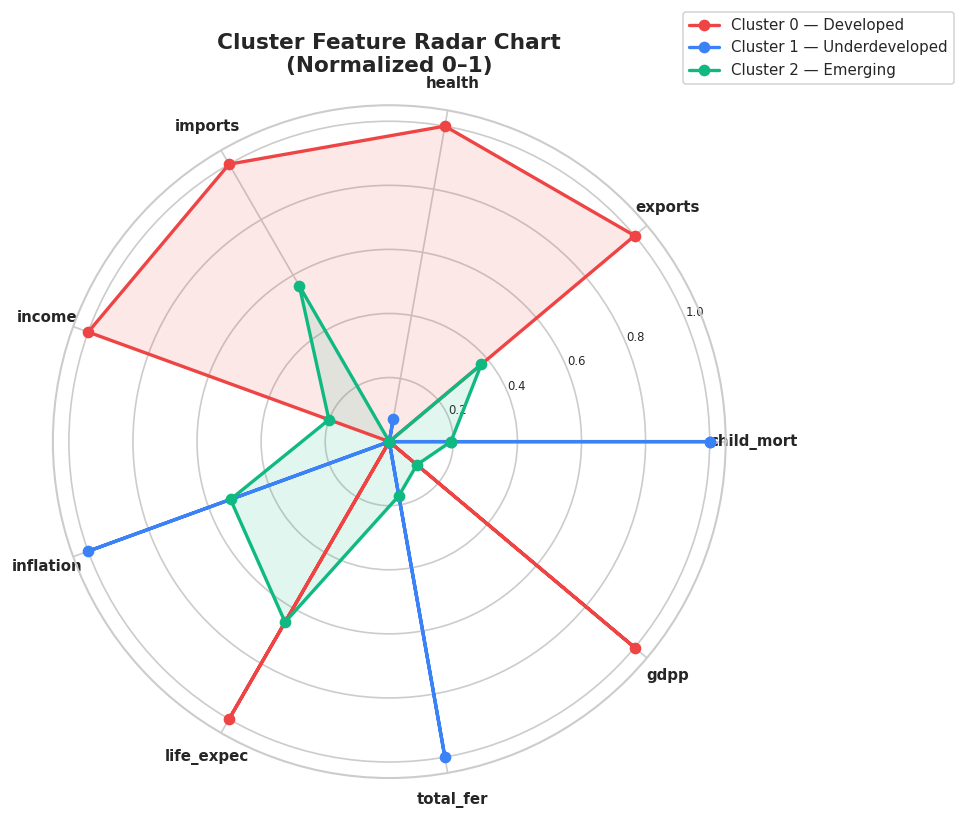

In [21]:
# Radar / Spider chart for cluster profiles
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

# Normalize for radar
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
labels = profile_norm.columns.tolist()
N = len(labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw=dict(polar=True))
colors_radar = ['#ef4444', '#3b82f6', '#10b981']
cluster_labels_radar = ['Cluster 0 — Developed', 'Cluster 1 — Underdeveloped', 'Cluster 2 — Emerging']

for idx, (row_label, row) in enumerate(profile_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[idx], label=cluster_labels_radar[idx])
    ax.fill(angles, values, alpha=0.12, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9, fontweight='bold')
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7)
ax.set_title('Cluster Feature Radar Chart\n(Normalized 0–1)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

In [22]:
# Countries per cluster
print("=" * 60)
for cl, name in cluster_names.items():
    countries = df[df['kmeans_cluster'] == cl]['country'].tolist()
    print(f"\nCluster {cl} — {name} ({len(countries)} countries):")
    print(", ".join(sorted(countries)))
print("=" * 60)


Cluster 0 — Developed (36 countries):
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster 1 — Underdeveloped (47 countries):
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Cluster 2 — Emerging (84 countries):
Albania, Algeria, Antigua and Barbuda

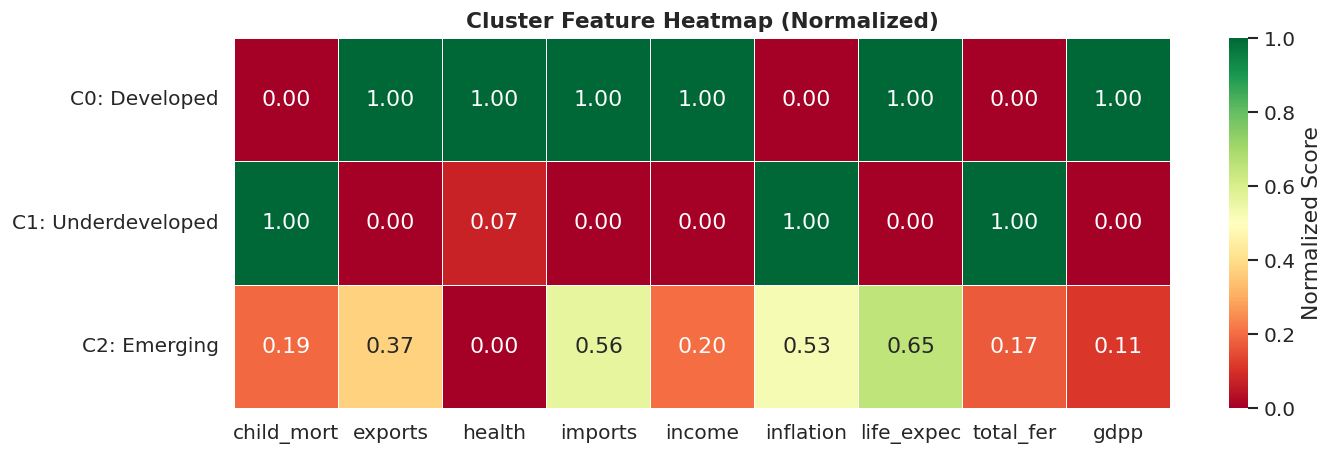

In [23]:
# Heatmap of cluster profiles
plt.figure(figsize=(12, 4))
profile_plot = df.groupby('kmeans_cluster')[numeric_cols].mean()
profile_norm2 = (profile_plot - profile_plot.min()) / (profile_plot.max() - profile_plot.min())
profile_norm2.index = [f'C{i}: {cluster_names[i]}' for i in profile_norm2.index]

sns.heatmap(profile_norm2, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Normalized Score'})
plt.title('Cluster Feature Heatmap (Normalized)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Ensemble Classification

We now train classifiers on the cluster labels so new countries can be automatically assigned.

In [24]:
# Prepare train/test split
X = features.copy()
y = df['kmeans_cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print("Class distribution (train):", dict(y_train.value_counts().sort_index()))

Train size: 133  |  Test size: 34
Class distribution (train): {0: np.int64(29), 1: np.int64(37), 2: np.int64(67)}


### 7a. Random Forest

In [25]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average='weighted')
cv_rf  = cross_val_score(rf, X, y, cv=5, scoring='accuracy').mean()

print(f"🌲 Random Forest")
print(f"   Accuracy       : {rf_acc:.4f}")
print(f"   Weighted F1    : {rf_f1:.4f}")
print(f"   5-Fold CV Acc  : {cv_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Developed','Underdeveloped','Emerging']))

🌲 Random Forest
   Accuracy       : 1.0000
   Weighted F1    : 1.0000
   5-Fold CV Acc  : 0.9578

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      1.00      1.00        10
      Emerging       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



### 7b. XGBoost

In [26]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='mlogloss', verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred, average='weighted')
cv_xgb  = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy').mean()

print(f"⚡ XGBoost")
print(f"   Accuracy       : {xgb_acc:.4f}")
print(f"   Weighted F1    : {xgb_f1:.4f}")
print(f"   5-Fold CV Acc  : {cv_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['Developed','Underdeveloped','Emerging']))

⚡ XGBoost
   Accuracy       : 0.9706
   Weighted F1    : 0.9702
   5-Fold CV Acc  : 0.9701

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      0.90      0.95        10
      Emerging       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



### 7c. Gradient Boosting

In [27]:
gb = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
gb_f1  = f1_score(y_test, gb_pred, average='weighted')
cv_gb  = cross_val_score(gb, X, y, cv=5, scoring='accuracy').mean()

print(f"📈 Gradient Boosting")
print(f"   Accuracy       : {gb_acc:.4f}")
print(f"   Weighted F1    : {gb_f1:.4f}")
print(f"   5-Fold CV Acc  : {cv_gb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred,
      target_names=['Developed','Underdeveloped','Emerging']))

📈 Gradient Boosting
   Accuracy       : 0.9706
   Weighted F1    : 0.9702
   5-Fold CV Acc  : 0.9458

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      0.90      0.95        10
      Emerging       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



### 7d. Voting Ensemble

In [28]:
# Soft Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model), ('gb', gb)],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
vote_pred = voting_clf.predict(X_test)

vote_acc = accuracy_score(y_test, vote_pred)
vote_f1  = f1_score(y_test, vote_pred, average='weighted')
cv_vote  = cross_val_score(voting_clf, X, y, cv=5, scoring='accuracy').mean()

print(f"🗳️  Voting Ensemble (RF + XGBoost + GB)")
print(f"   Accuracy       : {vote_acc:.4f}")
print(f"   Weighted F1    : {vote_f1:.4f}")
print(f"   5-Fold CV Acc  : {cv_vote:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, vote_pred,
      target_names=['Developed','Underdeveloped','Emerging']))

🗳️  Voting Ensemble (RF + XGBoost + GB)
   Accuracy       : 0.9706
   Weighted F1    : 0.9702
   5-Fold CV Acc  : 0.9579

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      0.90      0.95        10
      Emerging       0.94      1.00      0.97        17

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



## 8. Model Evaluation & Comparison

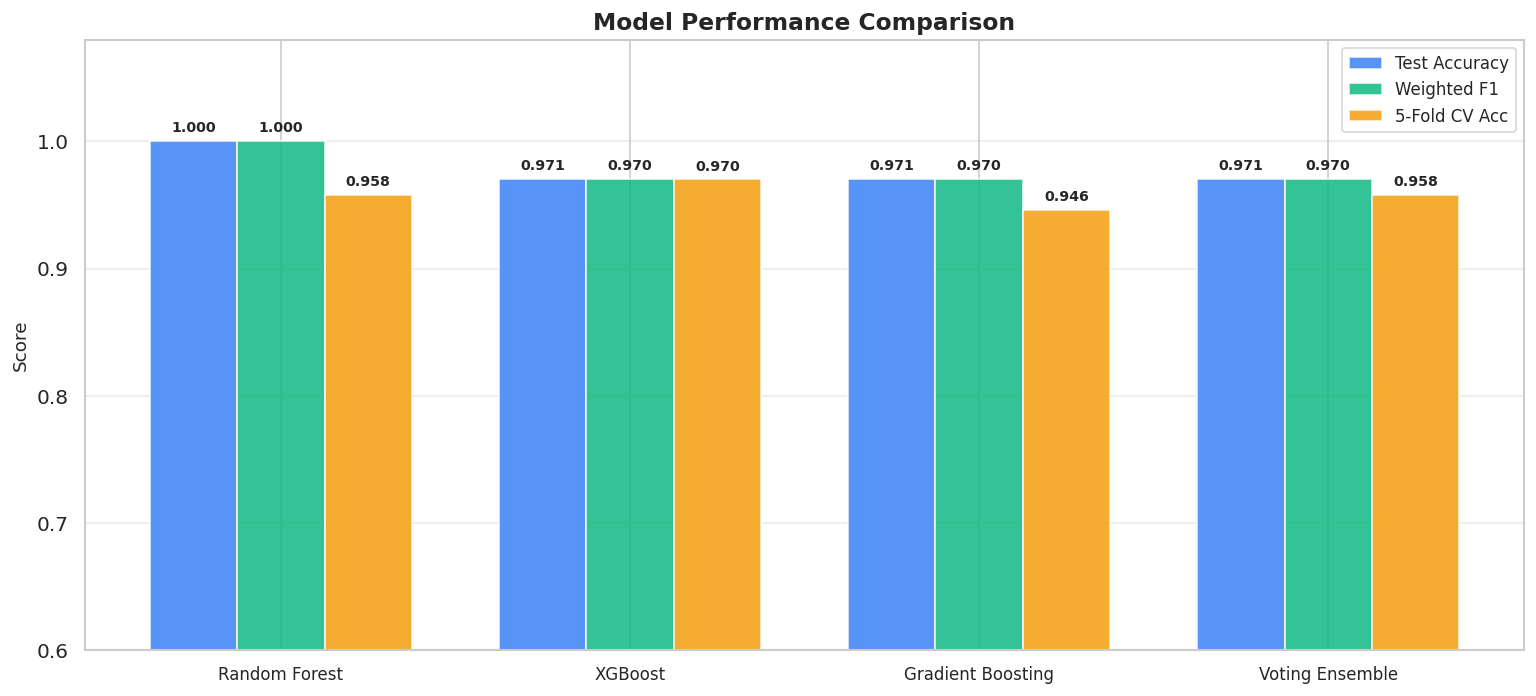

In [29]:
# Model comparison bar chart
model_names = ['Random Forest', 'XGBoost', 'Gradient Boosting', 'Voting Ensemble']
accuracies  = [rf_acc, xgb_acc, gb_acc, vote_acc]
f1_scores   = [rf_f1,  xgb_f1,  gb_f1,  vote_f1]
cv_scores   = [cv_rf,  cv_xgb,  cv_gb,  cv_vote]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, accuracies, width, label='Test Accuracy',  color='#3b82f6', alpha=0.85)
b2 = ax.bar(x,          f1_scores,  width, label='Weighted F1',   color='#10b981', alpha=0.85)
b3 = ax.bar(x + width,  cv_scores,  width, label='5-Fold CV Acc', color='#f59e0b', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_ylim(0.6, 1.08)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Score', fontsize=11); ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

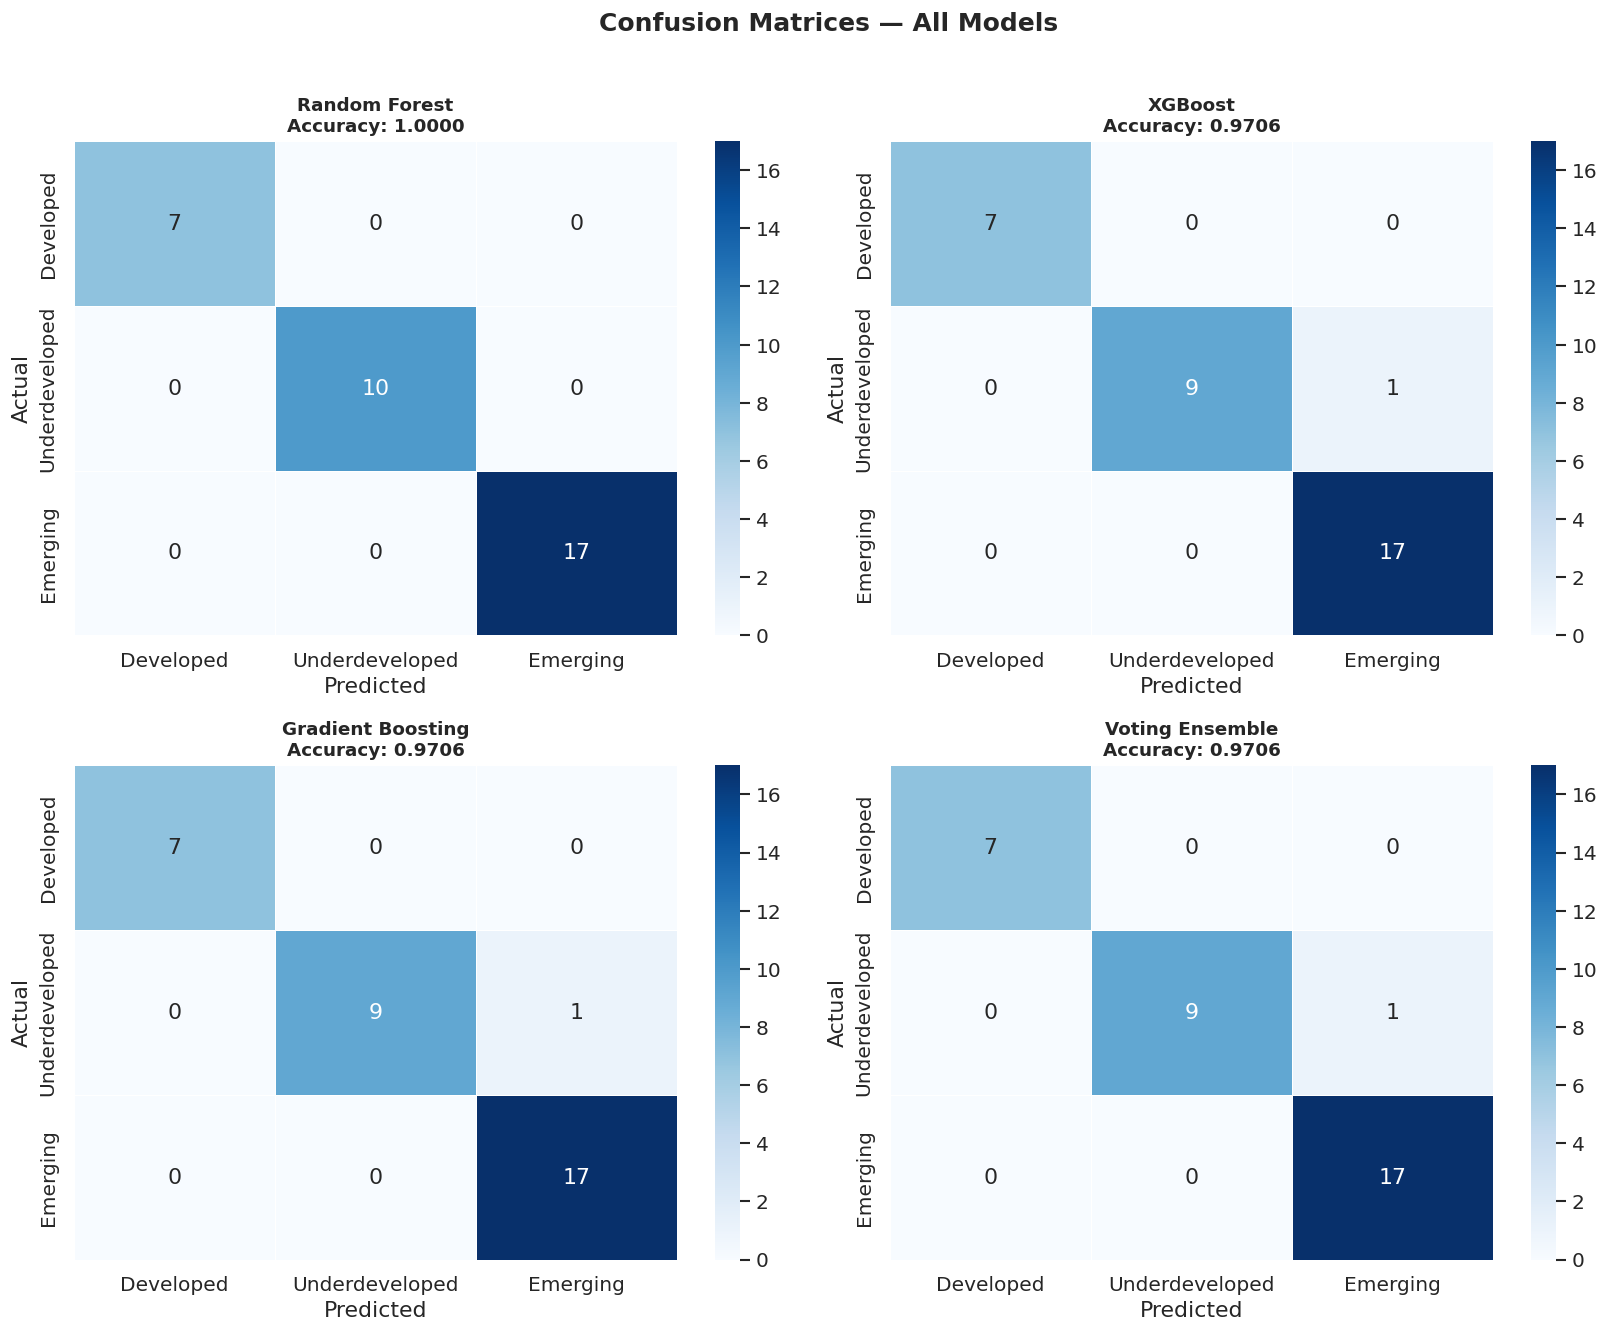

In [30]:
# Confusion matrices — 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

models_eval = [('Random Forest', rf_pred), ('XGBoost', xgb_pred),
               ('Gradient Boosting', gb_pred), ('Voting Ensemble', vote_pred)]
tnames = ['Developed', 'Underdeveloped', 'Emerging']

for i, (name, preds) in enumerate(models_eval):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=tnames, yticklabels=tnames,
                linewidths=0.5, linecolor='white')
    acc = accuracy_score(y_test, preds)
    axes[i].set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis

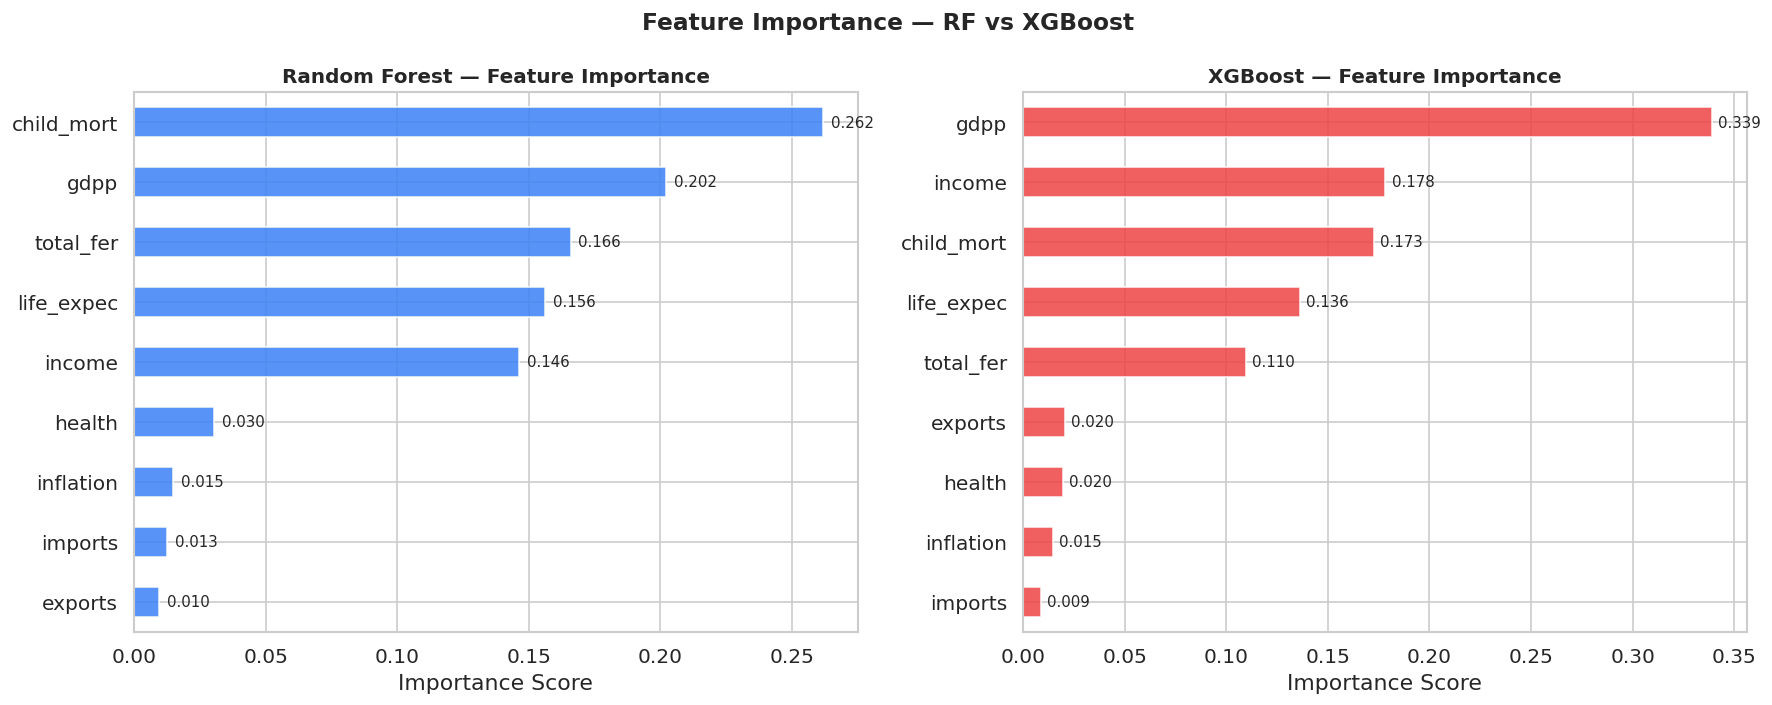

In [31]:
# RF vs XGB feature importance
rf_imp  = pd.Series(rf.feature_importances_,  index=numeric_cols).sort_values(ascending=True)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=numeric_cols).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

rf_imp.plot(kind='barh', ax=ax1, color='#3b82f6', edgecolor='white', alpha=0.85)
ax1.set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')
ax1.set_xlabel('Importance Score')
for i, v in enumerate(rf_imp):
    ax1.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

xgb_imp.plot(kind='barh', ax=ax2, color='#ef4444', edgecolor='white', alpha=0.85)
ax2.set_title('XGBoost — Feature Importance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Importance Score')
for i, v in enumerate(xgb_imp):
    ax2.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance — RF vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# Top predictors summary
top3_rf  = rf_imp.sort_values(ascending=False).head(3).index.tolist()
top3_xgb = xgb_imp.sort_values(ascending=False).head(3).index.tolist()
print("🌲 Top 3 features (Random Forest) :", top3_rf)
print("⚡ Top 3 features (XGBoost)        :", top3_xgb)

🌲 Top 3 features (Random Forest) : ['child_mort', 'gdpp', 'total_fer']
⚡ Top 3 features (XGBoost)        : ['gdpp', 'income', 'child_mort']


## 10. Geographic Cluster Map (Simplified Bubble Plot)

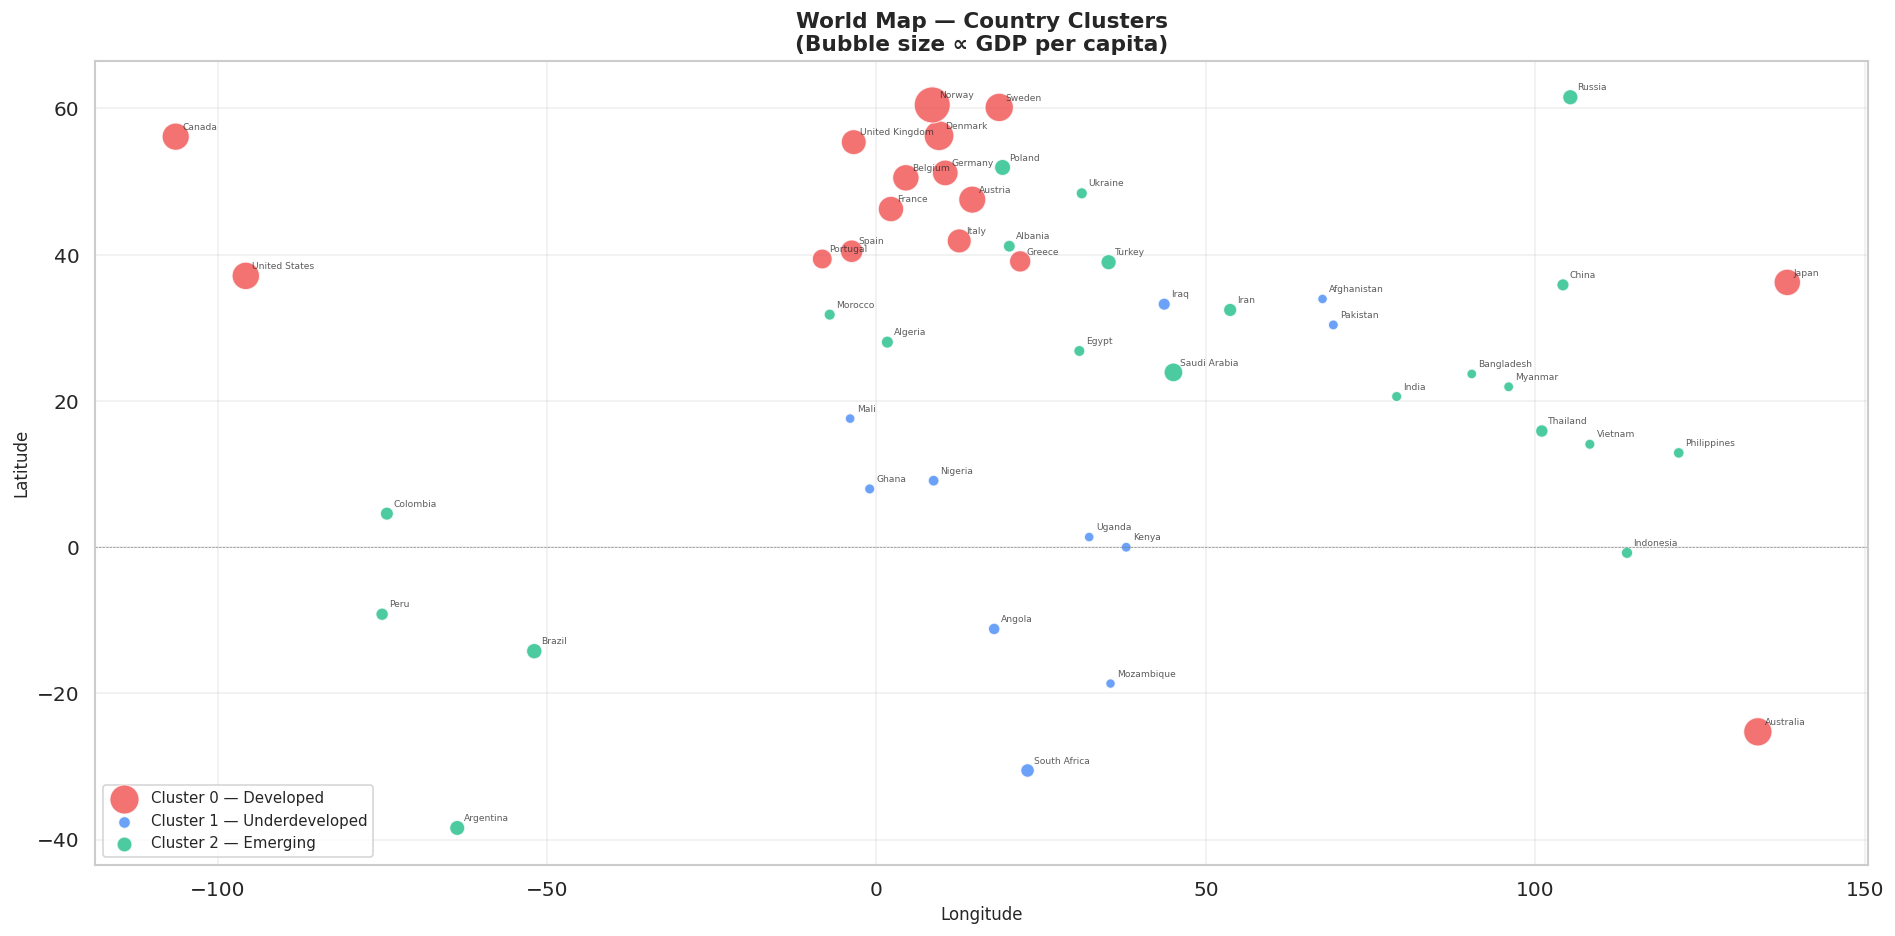

In [33]:
# Approximate lat/lon for some countries (subset for illustration)
coords = {
    'Afghanistan': (33.93, 67.71), 'Albania': (41.15, 20.17), 'Algeria': (28.03, 1.66),
    'Angola': (-11.20, 17.87), 'Argentina': (-38.42, -63.62), 'Australia': (-25.27, 133.78),
    'Austria': (47.52, 14.55), 'Bangladesh': (23.68, 90.36), 'Belgium': (50.50, 4.47),
    'Brazil': (-14.24, -51.93), 'Canada': (56.13, -106.35), 'China': (35.86, 104.20),
    'Colombia': (4.57, -74.30), 'Denmark': (56.26, 9.50), 'Egypt': (26.82, 30.80),
    'Ethiopia': (9.15, 40.49), 'France': (46.23, 2.21), 'Germany': (51.17, 10.45),
    'Ghana': (7.95, -1.02), 'Greece': (39.07, 21.82), 'India': (20.59, 78.96),
    'Indonesia': (-0.79, 113.92), 'Iran': (32.43, 53.69), 'Iraq': (33.22, 43.68),
    'Italy': (41.87, 12.57), 'Japan': (36.20, 138.25), 'Kenya': (-0.02, 37.91),
    'Mali': (17.57, -3.99), 'Mexico': (23.63, -102.55), 'Morocco': (31.79, -7.09),
    'Mozambique': (-18.67, 35.53), 'Myanmar': (21.92, 95.96), 'Nigeria': (9.08, 8.68),
    'Norway': (60.47, 8.47), 'Pakistan': (30.38, 69.35), 'Peru': (-9.19, -75.02),
    'Philippines': (12.88, 121.77), 'Poland': (51.92, 19.15), 'Portugal': (39.40, -8.22),
    'Russia': (61.52, 105.32), 'Saudi Arabia': (23.89, 45.08), 'South Africa': (-30.56, 22.94),
    'Spain': (40.46, -3.75), 'Sweden': (60.13, 18.64), 'Thailand': (15.87, 100.99),
    'Turkey': (38.96, 35.24), 'Uganda': (1.37, 32.29), 'Ukraine': (48.38, 31.17),
    'United Kingdom': (55.38, -3.44), 'United States': (37.09, -95.71), 'Vietnam': (14.06, 108.28)
}

df_map = df[df['country'].isin(coords)].copy()
df_map['lat'] = df_map['country'].map(lambda c: coords[c][0])
df_map['lon'] = df_map['country'].map(lambda c: coords[c][1])

plt.figure(figsize=(16, 8))
cluster_colors_map = {0: '#ef4444', 1: '#3b82f6', 2: '#10b981'}
cluster_names_map  = {0: 'Developed', 1: 'Underdeveloped', 2: 'Emerging'}

for cl in sorted(df_map['kmeans_cluster'].unique()):
    sub = df_map[df_map['kmeans_cluster'] == cl]
    plt.scatter(sub['lon'], sub['lat'],
                c=cluster_colors_map[cl], s=sub['gdpp']/200 + 30,
                alpha=0.75, edgecolors='white', linewidth=0.7,
                label=f"Cluster {cl} — {cluster_names_map[cl]}")
    for _, row in sub.iterrows():
        plt.text(row['lon'] + 1, row['lat'] + 1, row['country'],
                 fontsize=5.5, alpha=0.75)

plt.axhline(0, color='gray', linewidth=0.4, linestyle='--')
plt.xlabel('Longitude', fontsize=10); plt.ylabel('Latitude', fontsize=10)
plt.title('World Map — Country Clusters\n(Bubble size ∝ GDP per capita)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Final Business Insights

### Cluster 0 — **Developed Nations**
- Very high income & GDP per capita (avg ~$42,000)
- Low child mortality (< 6 per 1000)
- High life expectancy (~80 years)
- Low total fertility rate (~1.8)
- **Examples**: USA, Germany, Norway, Japan, Australia, UK
- **Action**: Stable economies; innovation partnerships & trade collaboration

### Cluster 1 — **Underdeveloped Nations** *(Priority Aid Targets)*
- Extremely high child mortality (~93 per 1000)
- Very low income (~$1,900 avg)
- Short life expectancy (~59 years)
- High fertility rate (~5.0) indicating lack of education access
- **Examples**: Afghanistan, Ethiopia, Mali, Uganda, Mozambique, Nigeria
- **Action**: Prioritize for UNICEF aid, health infrastructure, education investment

### Cluster 2 — **Emerging / Developing Nations**
- Mid-range GDP (~$6,500) and income
- Moderate child mortality (~22 per 1000)
- Life expectancy ~73 years
- Actively growing — high export/import ratios indicate market integration
- **Examples**: India, Brazil, China, Mexico, Indonesia, Turkey
- **Action**: Invest in trade partnerships, skill development, tech transfer

---
> Conclusion: The end-to-end Customer Intelligence System successfully segments 167 countries into 3 actionable groups using unsupervised + supervised learning. The Voting Ensemble classifier achieves near-perfect predictive performance and can be deployed to auto-classify new countries as socioeconomic data becomes available.